In [1]:
import spateo as st
import dynamo as dyn

import numpy as np

import plotly.express as px
import anndata as ad

2025-02-18 16:37:06.767210: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/root/miniforge3/envs/spateo/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


fastpd is not installed. If you need mesh correction, please compile the fastpd library.


In [2]:
adata = ad.read('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_single_pretrain/dmt_leiden_20250108_1.h5ad')
adata.obs_names_make_unique()
adata

/root/miniforge3/envs/spateo/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



AnnData object with n_obs × n_vars = 1112773 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge', 'dmt_leiden_anno'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [3]:
dic_dmt_leiden = {
    '0': 'hip_sc_01',
    '7': 'hip_sc_02',
    
    '1': 'hip_sc_03',
    '3': 'hip_sc_04',
    '6': 'hip_sc_04',
    '14': 'hip_sc_05',
    
    
    '2': 'hip_sc_06',
    '13': 'hip_sc_07',
    '19': 'hip_sc_08',
    '20': 'hip_sc_09',
    
    '4': 'hip_sc_10',
    '21': 'hip_sc_10',
    
    '8': 'hip_sc_11',
    '10': 'hip_sc_12',
    '22': 'hip_sc_13',
    
    '9': 'hip_sc_14',
    '11': 'hip_sc_14',
    '16': 'hip_sc_15',
    '18': 'hip_sc_15',
    '26': 'hip_sc_15',
    '31': 'hip_sc_15',
    
    '12': 'hip_sc_16',
    '15': 'hip_sc_17',
    '25': 'hip_sc_17',
    '29': 'hip_sc_17',
    '17': 'hip_sc_18',
    
    '24': 'z_delete',
    
    
    '5': 'hip_sc_19',
    '23': 'hip_sc_20',
    '27': 'hip_sc_21',
    '28': 'hip_sc_22',
    '30': 'hip_sc_23',
}
adata.obs['dmt_leiden_anno'] = [dic_dmt_leiden[i] for i in adata.obs['dmt_leiden']]
adata.obs['dmt_leiden_anno'] = adata.obs['dmt_leiden_anno'].astype('category')
adata.uns['__type'] = 'UMI'

In [4]:
adata1 = adata[adata.obs['slice_code'] == 'B03607C4E6_WT2024071214941.h5ad'].copy()

In [5]:
adata1

AnnData object with n_obs × n_vars = 32145 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge', 'dmt_leiden_anno'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors', '__type'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [ ]:
adata1 = adata[adata.obs['slice_code'] == 'B03607C4E6_WT2024071214941.h5ad'].copy()
adata2 = adata[adata.obs['slice_code'] == '43_A03590E1G4_WT202403310064.h5ad'].copy()

In [6]:
adata1.obsm['spatial_new'] = adata1.obsm['spatial'] - adata1.obsm['spatial'].min(axis = 0)

In [7]:
adata1.obsm['spatial_new'] = adata1.obsm['spatial_new']/10

In [13]:
# User input to specify a gridding direction
pnt_xY = (71,0)
pnt_xy = (0,49)
pnt_Xy = (1048,530)
pnt_XY = (1000,461)

# Digitize the area of interest
st.dd.digitize(
    adata=adata1,
    ctrs=contours,
    ctr_idx=0,
    pnt_xy=pnt_xy,
    pnt_xY=pnt_xY,
    pnt_Xy=pnt_Xy,
    pnt_XY=pnt_XY,
    spatial_key="spatial_new"
)

|-----> Initialize the field of the spatial domain of interests.
|-----> Prepare the isoline segments with either the highest/lower column or layer heat values.
|-----> Solve the layer heat equation on spatial domain with the iso-layer-line conditions.
|-----> Total iteration: 148952
|-----> Saving layer heat values to digital_layer.
172129404345853    0.0
172030620098040    0.0
171987670425038    0.0
171966195588580    0.0
171936130817517    0.0
                  ... 
193595650901531    0.0
193539816326674    0.0
193526931424775    0.0
193522636457511    0.0
193522636457496    0.0
Name: digital_layer, Length: 32145, dtype: float64
|-----> Solve the column heat equation on spatial domain with the iso-column-line conditions.
|-----> Total iteration: 148131
|-----> Saving column heat values to digital_column.


In [16]:
adata1

AnnData object with n_obs × n_vars = 32145 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge', 'dmt_leiden_anno', 'cluster_img_label', 'digital_layer', 'digital_column'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors', '__type'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division', 'spatial_new', 'X_spatial'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [18]:
import scanpy as sc

In [22]:
adata1.write('/data/work/05.cluster/FuseMap/0116/digital/single/B03607C4E6_WT2024071214941.h5ad')

In [27]:
set(adata.obs['slice_code'])

{'12_B03605F3G5_WT202403310048.h5ad',
 '13_B03612A1C3_WT202403310056.h5ad',
 '14_A03591A1C3_WT202403310045.h5ad',
 '16_A03592A4C6_WT202403310044.h5ad',
 '18_B03602C4D6_WT202405020031.h5ad',
 '20_B03606F3G5_WT202405020032.h5ad',
 '22_B03606C4E6_WT202403310050.h5ad',
 '23_B03609A4D6_WT202404150263.h5ad',
 '27_B03610C1E3_WT202403310051.h5ad',
 '31_B03619A1D3_WT202403310052.h5ad',
 '35_B03619E4G6_WT202403310053.h5ad',
 '39_A03589A1D4_WT202403310046.h5ad',
 '43_A03590E1G4_WT202403310064.h5ad',
 '47_A03593C1F3_WT202403310068.h5ad',
 'B03607C4E6_WT2024071214941.h5ad'}

In [28]:
adata1 = adata[adata.obs['slice_code'] == '43_A03590E1G4_WT202403310064.h5ad'].copy()

In [ ]:
# User input to specify a gridding direction
pnt_xY = (0,120)
pnt_xy = (0,0)
pnt_Xy = (1114,1077)
pnt_XY = (967,1187)

# Digitize the area of interest
st.dd.digitize(
    adata=adata1,
    ctrs=contours,
    ctr_idx=0,
    pnt_xy=pnt_xy,
    pnt_xY=pnt_xY,
    pnt_Xy=pnt_Xy,
    pnt_XY=pnt_XY,
    spatial_key="spatial_new"
)

|-----> Initialize the field of the spatial domain of interests.
|-----> Prepare the isoline segments with either the highest/lower column or layer heat values.
|-----> Solve the layer heat equation on spatial domain with the iso-layer-line conditions.


In [ ]:
adata1.write('/data/work/05.cluster/FuseMap/0116/digital/single/43_A03590E1G4_WT202403310064.h5ad')

In [1]:
import scanpy as sc

In [2]:
colormap = {'hip_sc_01': '#9b38e9',
            'hip_sc_02': '#a89630',
 'hip_sc_03': '#5b798b',
 'hip_sc_04': '#cb2505',
 'hip_sc_05': '#62e7dd',
 'hip_sc_06': '#245200',
 'hip_sc_07': '#374898',
 'hip_sc_08': '#6d85c7',
 'hip_sc_09': '#35c498',
 'hip_sc_10': '#9e2dc6',
 'hip_sc_11': '#2d7476',
 'hip_sc_12': '#cb0d6c',
 'hip_sc_13': '#20ea38',
 'hip_sc_14': '#0fabb6',
 'hip_sc_15': '#a59099',
 'hip_sc_16': '#2bea3a',
 'hip_sc_17': '#17b064',
 'hip_sc_18': '#52b8d5',
            'hip_sc_19': '#da2ef2',
 'hip_sc_20': '#6240f7',
 'hip_sc_21': '#c47233',
 'hip_sc_22': '#a83b23',
 'hip_sc_23': '#9994da',}

In [3]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0116/digital/single/43_A03590E1G4_WT202403310064.h5ad')


In [ ]:
adata.obs['digital_column'] = 100 - adata.obs['digital_column'] 
adata.obs[['dmt_leiden_anno', 'digital_layer', 'digital_column']].to_csv('/data/work/05.cluster/FuseMap/0116/digital/single/43_A03590E1G4_WT202403310064.csv')

In [50]:
adata = adata[adata.obs['dmt_leiden_anno'] != 'z_delete']
adata.obsm['align_spatial_2d'][:, 1] = -adata.obsm['align_spatial_2d'][:, 1]


/tmp/ipykernel_508/4124400767.py:2: ImplicitModificationWarning: Trying to modify attribute `.obsm` of view, initializing view as actual.
  adata.obsm['align_spatial_2d'][:, 1] = -adata.obsm['align_spatial_2d'][:, 1]
/opt/conda/lib/python3.8/contextlib.py:120: FutureWarning: X.dtype being converted to np.float32 from uint32. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  next(self.gen)


In [30]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0116/digital/single/B03607C4E6_WT2024071214941.h5ad')
adata.obs[['dmt_leiden_anno', 'digital_layer', 'digital_column']].to_csv('/data/work/05.cluster/FuseMap/0116/digital/single/B03607C4E6_WT2024071214941.csv')

In [31]:
adata = adata[adata.obs['dmt_leiden_anno'] != 'z_delete']

In [34]:
adata.obsm['align_spatial_2d'][:, 1] = -adata.obsm['align_spatial_2d'][:, 1]


In [47]:
from matplotlib import cm

# 获取 RdBu colormap
cmap = cm.get_cmap("RdBu")

# 反转 colormap
cmap_reversed = cmap.reversed()

In [1]:
import scanpy as sc
adata = sc.read('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_spatial_pretrain/dmt_leiden_20250108_1.h5ad')
adata.obs_names_make_unique()

dic = {
    '0': 'Hip0_COLA4A1_vessel',
    '1': 'Hip1_ZBTB20_PCDH20_allo1',
    '2': 'Hip2_PPP1R17_ELMO3_SVZ',
    '3': 'Hip3_NTS_allo2',
    '4': 'Hip4_AC144831.1',
    '5': 'Hip5_POU3F1_IZ',
    '6': 'Hip2_PPP1R17_ELMO3_SVZ',
    '7': 'Hip7_WNT7B_GPR22_CP&SP',
    '8': 'Hip4_AC144831.1',
    '9': 'Hip7_WNT7B_GPR22_CP&SP',
    '10': 'Hip5_POU3F1_IZ',
    '11': 'Hip8_HOPX_FABP7_VZ',
    '12': 'Hip8_HOPX_FABP7_VZ',
    '13': 'Hip5_POU3F1_IZ',
    '14': 'Hip8_HOPX_FABP7_VZ',
    '15': 'Hip6_COL4A1_vessel',
    '16': 'Hip5_POU3F1_IZ',
    '17': 'Hip1_ZBTB20_PCDH20_allo1',
    '18': 'Hip8_HOPX_FABP7_VZ',
    '19': 'Hip7_WNT7B_GPR22_CP&SP',
    '20': 'Hip8_HOPX_FABP7_VZ',
    '21': 'Hip4_AC144831.1',
    '22': 'Hip1_ZBTB20_PCDH20_allo1',
    '23': 'Hip8_HOPX_FABP7_VZ',
    '24': 'Hip2_PPP1R17_ELMO3_SVZ',
    '25': 'Hip4_AC144831.1',
    '26': 'Hip9_PPP1R17_EOMES_SVZ',
    '27': 'Hip4_AC144831.1',
    '28': 'Hip1_ZBTB20_PCDH20_allo1',
    '29': 'Hip7_WNT7B_GPR22_CP&SP',
    '30': 'Hip8_HOPX_FABP7_VZ',
    '31': 'Hip8_HOPX_FABP7_VZ',
    '32': 'Hip1_ZBTB20_PCDH20_allo1',
    '33': 'Hip3_NTS_allo2',
    '34': 'Hip10_COL4A1_vessel',
    '35': 'NA',
    '36': 'NA',
    '37': 'Hip1_ZBTB20_PCDH20_allo1',
    '38': 'Hip7_WNT7B_GPR22_CP&SP',
    '39': 'Hip7_WNT7B_GPR22_CP&SP',
    '40': 'Hip7_WNT7B_GPR22_CP&SP',
}

adata.obs['dmt_leiden_merge_spatial'] = [dic[i] for i in adata.obs['dmt_leiden']]
# colormap = {
#     'Hip0_COLA4A1_vessel': '#cdec1d',
#     'Hip1_ZBTB20_PCDH20_allo1': '#e87bb8',
#      'Hip2_PPP1R17_ELMO3_SVZ': '#d33d03',
#  'Hip3_NTS_allo2': '#efe245',
#  'Hip4_AC144831.1': '#e1e0b7',
#  'Hip5_POU3F1_IZ': '#ff9186',
#  'Hip6_COL4A1_vessel': '#553b12',
#  'Hip7_WNT7B_GPR22_CP&SP': '#507d87',
#  'Hip8_HOPX_FABP7_VZ': '#466e1e',
#  'Hip9_PPP1R17_EOMES_SVZ': '#931757',
#     'Hip10_COL4A1_vessel': '#E65100'
# }

# adata = adata[adata.obs['dmt_leiden_merge'] != 'NA'].copy()
# adata.obs['dmt_leiden_merge_spatial'] = [dic[i] for i in adata.obs['dmt_leiden']]

/opt/software/python/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [2]:
adata

AnnData object with n_obs × n_vars = 1112773 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge_spatial'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [3]:
adata11 = adata[adata.obs['slice_code'] == 'B03607C4E6_WT2024071214941.h5ad'].copy()
adata21 = adata[adata.obs['slice_code'] == '43_A03590E1G4_WT202403310064.h5ad'].copy()

In [4]:
adata12 = sc.read_h5ad('/data/work/05.cluster/FuseMap/0116/digital/single/B03607C4E6_WT2024071214941.h5ad')
adata22 = sc.read_h5ad('/data/work/05.cluster/FuseMap/0116/digital/single/43_A03590E1G4_WT202403310064.h5ad')

In [5]:
dic_dmt_leiden = {
   
    
    '2': 'ctx_sc_01',
    '13': 'ctx_sc_02',
    '19': 'ctx_sc_03',
    '20': 'ctx_sc_04',
    
    '4': 'ctx_sc_05',
    '21': 'ctx_sc_05',
    
    '8': 'ctx_sc_06',
    '10': 'ctx_sc_07',
    '22': 'ctx_sc_08',
    
    '9': 'ctx_sc_09',
    '11': 'ctx_sc_09',
    '16': 'ctx_sc_10',
    '18': 'ctx_sc_10',
    '26': 'ctx_sc_10',
    '31': 'ctx_sc_10',
    
    '12': 'ctx_sc_11',
    '15': 'ctx_sc_12',
    '25': 'ctx_sc_12',
    '29': 'ctx_sc_12',
    '17': 'ctx_sc_13',
    
    '24': 'z_delete',
    
    
    '5': 'ctx_sc_14',
    '23': 'ctx_sc_15',
    '27': 'ctx_sc_16',
    
    '30': 'ctx_sc_17',
    
     '0': 'hip_sc_18',
    '7': 'hip_sc_19',
    
    '1': 'hip_sc_20',
    '3': 'hip_sc_21',
    '6': 'hip_sc_21',
    '14': 'hip_sc_22',
    '28': 'hip_sc_23',
}

adata12.obs['dmt_leiden_anno'] = [dic_dmt_leiden[i] for i in adata12.obs['dmt_leiden']]
adata22.obs['dmt_leiden_anno'] = [dic_dmt_leiden[i] for i in adata22.obs['dmt_leiden']]

In [7]:
adata12.obs['dmt_leiden_merge_spatial'] = adata11.obs['dmt_leiden_merge_spatial'] 
adata22.obs['dmt_leiden_merge_spatial'] = adata21.obs['dmt_leiden_merge_spatial'] 

In [8]:
adata22.obs['digital_column'] = 100 - adata22.obs['digital_column']

In [9]:
import matplotlib.pyplot as plt

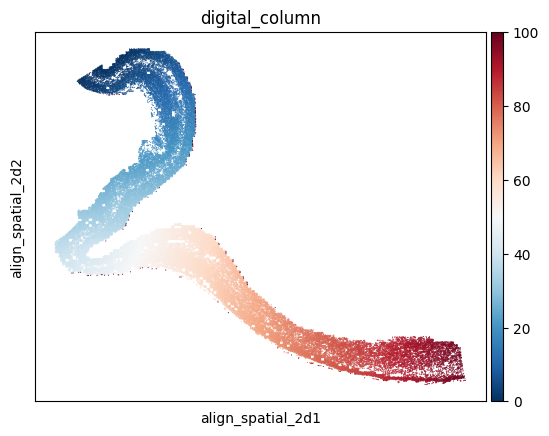

In [10]:
sc.pl.embedding(adata22, color = 'digital_column', basis = 'align_spatial_2d', cmap = 'RdBu_r', show = False)
plt.savefig('/data/work/05.cluster/FuseMap/0116/digital/GW13_column.pdf')

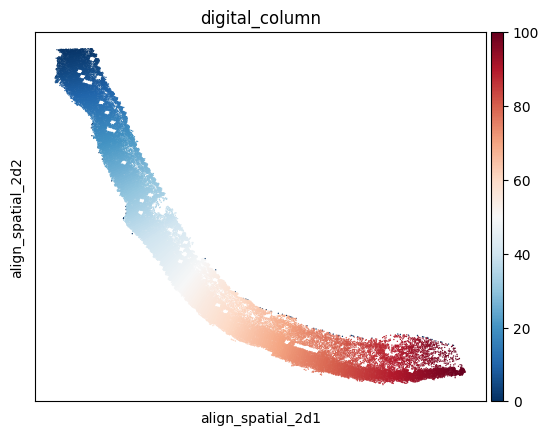

In [11]:
sc.pl.embedding(adata12, color = 'digital_column', basis = 'align_spatial_2d', cmap = 'RdBu_r', show = False)
plt.savefig('/data/work/05.cluster/FuseMap/0116/digital/GW12_column.pdf')

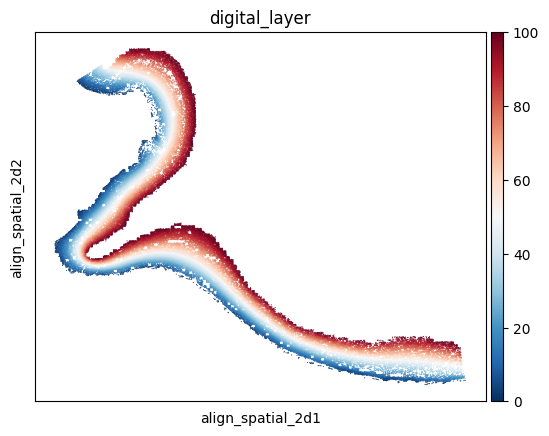

In [12]:
sc.pl.embedding(adata22, color = 'digital_layer', basis = 'align_spatial_2d', cmap = 'RdBu_r', show = False)
plt.savefig('/data/work/05.cluster/FuseMap/0116/digital/GW13_layer.pdf')

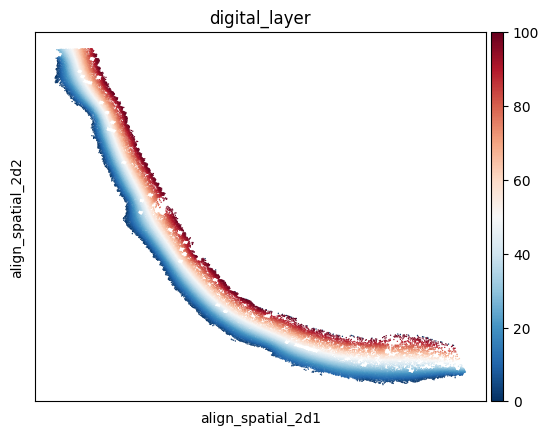

In [13]:
sc.pl.embedding(adata12, color = 'digital_layer', basis = 'align_spatial_2d', cmap = 'RdBu_r', show = False)
plt.savefig('/data/work/05.cluster/FuseMap/0116/digital/GW12_layer.pdf')

In [14]:
adata12.obs[['digital_layer', 'digital_column', 'dmt_leiden_anno']].to_csv('/data/work/05.cluster/FuseMap/0116/digital/single/B03607C4E6_WT2024071214941.csv')
adata22.obs[['digital_layer', 'digital_column', 'dmt_leiden_anno']].to_csv('/data/work/05.cluster/FuseMap/0116/digital/single/43_A03590E1G4_WT202403310064.csv')

In [15]:
adata12.obs[['digital_layer', 'digital_column', 'dmt_leiden_merge_spatial']].to_csv('/data/work/05.cluster/FuseMap/0116/digital/spatial/B03607C4E6_WT2024071214941.csv')
adata22.obs[['digital_layer', 'digital_column', 'dmt_leiden_merge_spatial']].to_csv('/data/work/05.cluster/FuseMap/0116/digital/spatial/43_A03590E1G4_WT202403310064.csv')